# MAPAS DE RAZONES DE ALUMNOS DOCENTES Y ESCUELAS

In [1]:
from pathlib import Path
import os

os.chdir("/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework")
print(Path.cwd())

/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework


--- Iniciando carga de archivos ---
✅ Archivos CSV cargados.
✅ Shapefile cargado.
✅ Datos procesados.
Generando mapa de Media Superior...


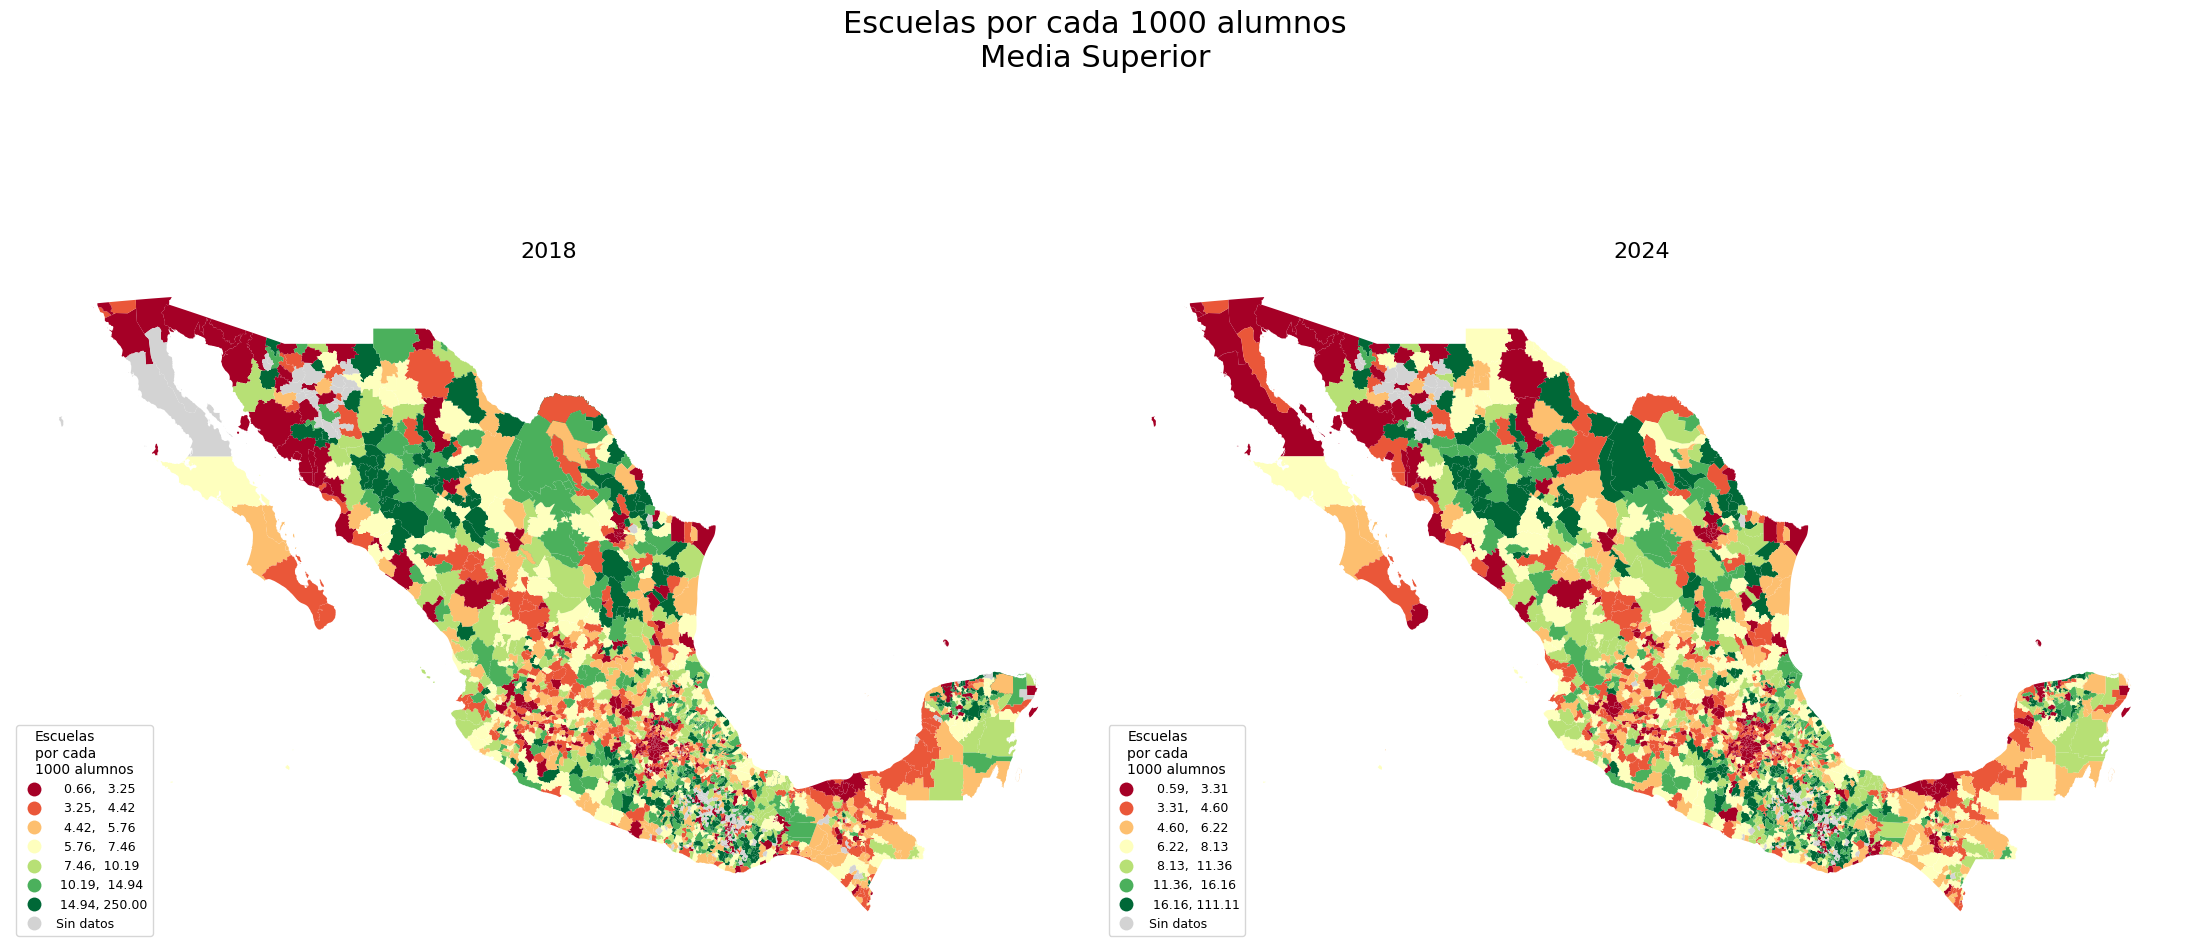

Generando mapa de Superior...


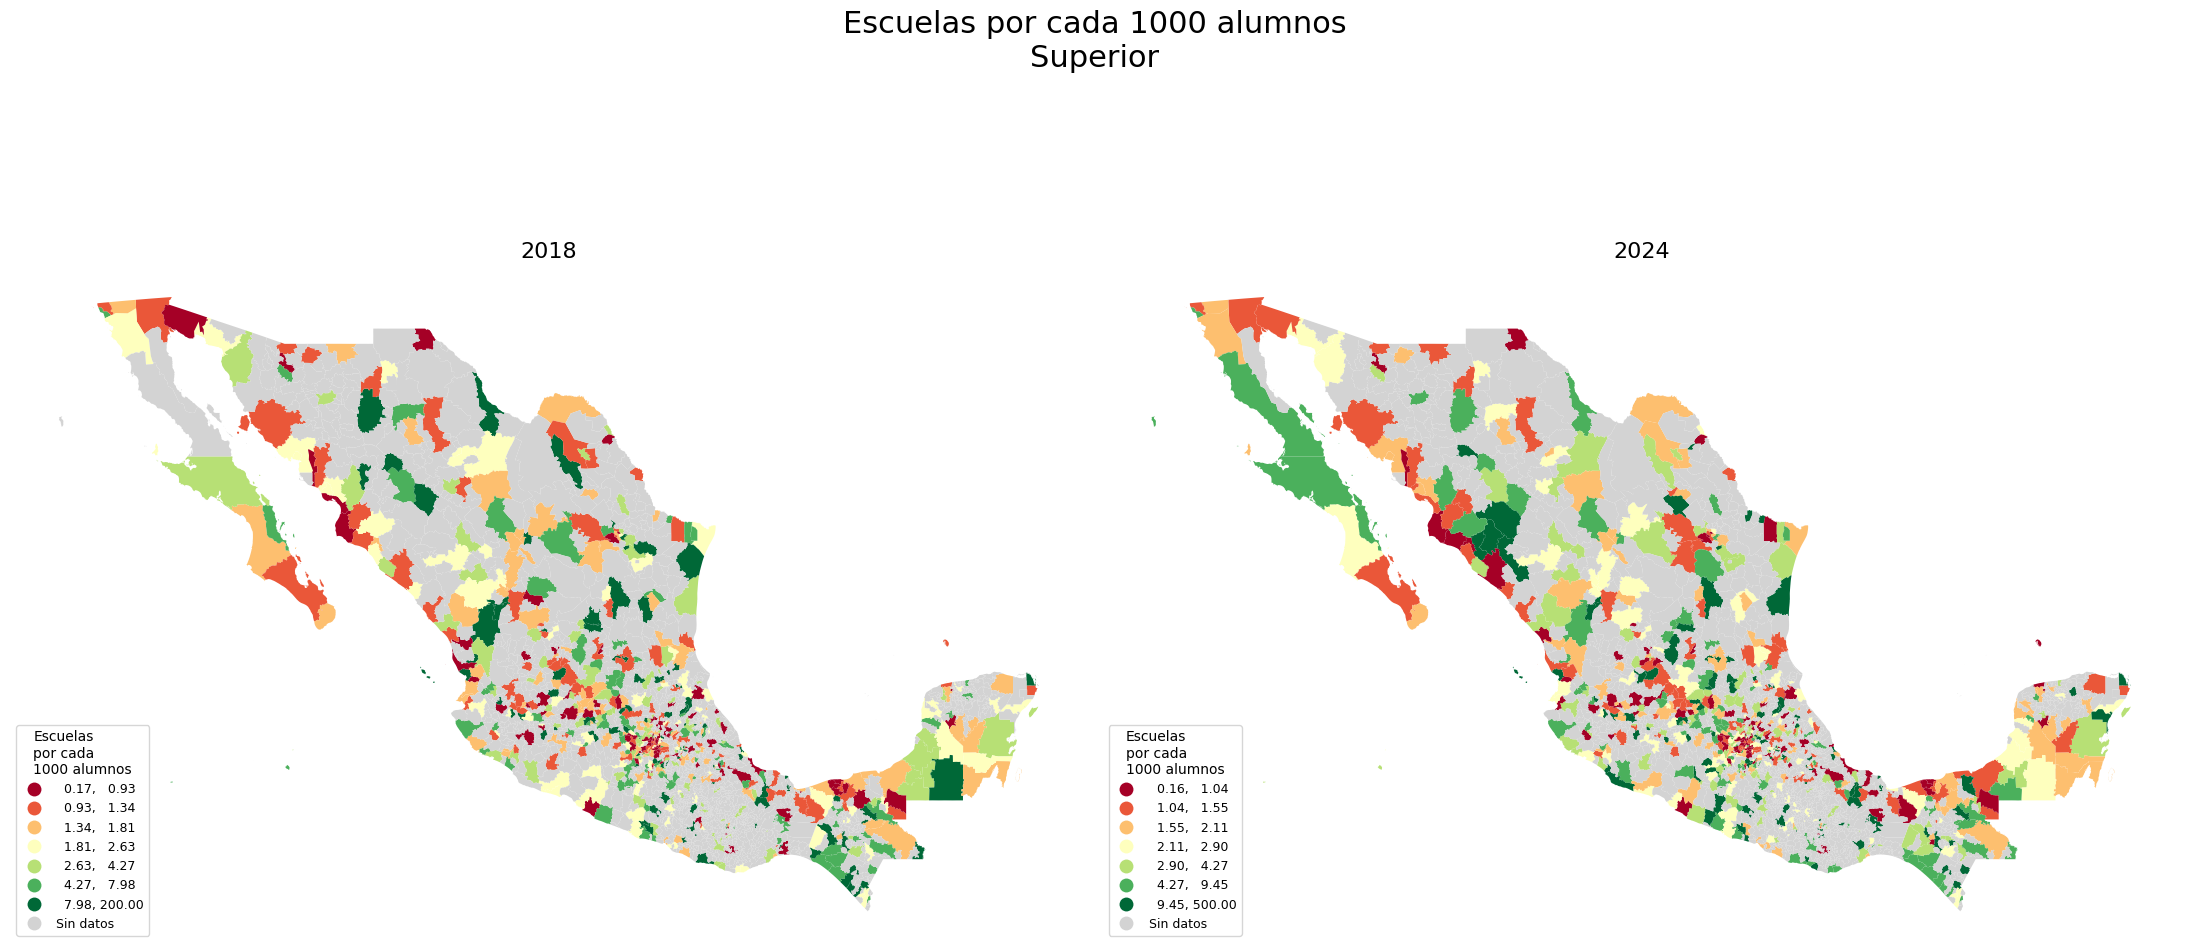


✅ Proceso terminado correctamente.


In [9]:
# ============================================================
# MAPAS: ESCUELAS POR CADA 1000 ALUMNOS
# (Media Superior y Superior, 2018 vs 2024)
# ============================================================

# Si no tienes instalado mapclassify, ejecuta una sola vez:
# !pip install mapclassify

# ------------------------------------------------------------
# 1. IMPORTAR LIBRERÍAS
# ------------------------------------------------------------
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 2. CARGA DE DATOS
# ------------------------------------------------------------
print("--- Iniciando carga de archivos ---")

ruta_base = r"data/processed/mapas"
ruta_mapa = r"data/processed/mapas"

# CSV
df_media_superior_2018 = pd.read_csv(
    f"{ruta_base}/media_superior_2018.csv",
    encoding="latin1"
)

df_media_superior_2024 = pd.read_csv(
    f"{ruta_base}/media_superior_2024.csv",
    encoding="latin1"
)

df_superior_2018 = pd.read_csv(
    f"{ruta_base}/superior_2018.csv",
    encoding="latin1"
)

df_superior_2024 = pd.read_csv(
    f"{ruta_base}/superior_2024.csv",
    encoding="latin1"
)

print("✅ Archivos CSV cargados.")

# Shapefile
mx = gpd.read_file(ruta_mapa)
print("✅ Shapefile cargado.")

# ------------------------------------------------------------
# 3. NOMBRES DE COLUMNAS
# ------------------------------------------------------------
col_alumnos = "Alumnos"
col_escuelas = "Escuelas"
col_geo_datos = "ubicageo"
col_geo_mapa = "CVEGEO"

# ------------------------------------------------------------
# 4. FUNCIÓN DE PROCESAMIENTO
# ------------------------------------------------------------
def procesar_dataframe(df):

    # Convertir a numérico
    df[col_alumnos] = pd.to_numeric(df[col_alumnos], errors="coerce")
    df[col_escuelas] = pd.to_numeric(df[col_escuelas], errors="coerce")

    # Razón alumnos por escuela
    df["razon_alumnos_escuelas"] = np.where(
        df[col_escuelas] > 0,
        df[col_alumnos] / df[col_escuelas],
        np.nan
    )

    # Escuelas por cada 1000 alumnos
    df["razon_escuelas_inv"] = np.where(
        df["razon_alumnos_escuelas"] > 0,
        (1 / df["razon_alumnos_escuelas"]) * 1000,
        np.nan
    )

    # Clave geográfica
    df[col_geo_datos] = pd.to_numeric(
        df[col_geo_datos],
        errors="coerce"
    ).astype("Int64")

    return df

# Procesar los cuatro archivos
df_media_superior_2018 = procesar_dataframe(df_media_superior_2018)
df_media_superior_2024 = procesar_dataframe(df_media_superior_2024)
df_superior_2018 = procesar_dataframe(df_superior_2018)
df_superior_2024 = procesar_dataframe(df_superior_2024)

# Procesar clave geográfica del mapa
mx[col_geo_mapa] = pd.to_numeric(
    mx[col_geo_mapa],
    errors="coerce"
).astype("Int64")

print("✅ Datos procesados.")

# ------------------------------------------------------------
# 5. FUNCIÓN PARA GRAFICAR
# ------------------------------------------------------------
def graficar_en_eje(mapa_base,
                    datos_df,
                    columna,
                    ax,
                    titulo):

    mapa = mapa_base.merge(
        datos_df,
        left_on=col_geo_mapa,
        right_on=col_geo_datos,
        how="left"
    )

    mapa.plot(
        column=columna,
        cmap="RdYlGn",
        scheme="quantiles",
        k=7,
        legend=True,
        ax=ax,
        legend_kwds={
            "loc": "lower left",
            "fontsize": 9,
            "frameon": True,
            "title": "Escuelas\npor cada\n1000 alumnos"
        },
        missing_kwds={
            "color": "lightgrey",
            "label": "Sin datos"
        }
    )

    ax.set_title(titulo, fontsize=16)
    ax.set_axis_off()

# ============================================================
# 6. MAPA 1
# MEDIA SUPERIOR
# ============================================================

print("Generando mapa de Media Superior...")

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(22,11)
)

fig.suptitle(
    "Escuelas por cada 1000 alumnos\nMedia Superior",
    fontsize=22
)

graficar_en_eje(
    mx,
    df_media_superior_2018,
    "razon_escuelas_inv",
    ax1,
    "2018"
)

graficar_en_eje(
    mx,
    df_media_superior_2024,
    "razon_escuelas_inv",
    ax2,
    "2024"
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

# ============================================================
# 7. MAPA 2
# SUPERIOR
# ============================================================

print("Generando mapa de Superior...")

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(22,11)
)

fig.suptitle(
    "Escuelas por cada 1000 alumnos\nSuperior",
    fontsize=22
)

graficar_en_eje(
    mx,
    df_superior_2018,
    "razon_escuelas_inv",
    ax1,
    "2018"
)

graficar_en_eje(
    mx,
    df_superior_2024,
    "razon_escuelas_inv",
    ax2,
    "2024"
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

print("\n✅ Proceso terminado correctamente.")

In [4]:
# --- 0. INSTALACIÓN (Ejecutar solo una vez si es necesario) ---
# Si no lo has hecho, quita el comentario de la siguiente línea y ejecútala
# !pip install mapclassify

# --- 1. IMPORTAR LIBRERÍAS ---
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# --- 2. CARGA DE TODOS LOS DATOS ---
print("--- Iniciando Carga de Archivos ---")
try:
    # Definir rutas
    ruta_base = r"data/processed/mapas"
    ruta_mapa = r"data/processed/mapas"

    # Cargar 4 archivos CSV
    df_media_superior_2018 = pd.read_csv(f"{ruta_base}\media_superior_2018.csv", encoding='latin1')
    df_superior_2018 = pd.read_csv(f"{ruta_base}\superior_2018.csv", encoding='latin1')
    df_media_superior_2024 = pd.read_csv(f"{ruta_base}\media_superior_2024.csv", encoding='latin1')
    df_superior_2024 = pd.read_csv(f"{ruta_base}\superior_2024.csv", encoding='latin1')
    print("✅ 4 Archivos CSV cargados.")
    
    # Cargar Shapefile
    mx = gpd.read_file(ruta_mapa)
    print("✅ Shapefile 'mx' cargado.")

except Exception as e:
    print(f"❌ ERROR AL CARGAR ARCHIVOS: {e}")
    # Si hay un error al cargar, es mejor detener el script
    raise SystemExit("Deteniendo script por error en carga de archivos.")

# --- 3. PROCESAMIENTO Y PREPARACIÓN ---

# ⚠️ Nombres de columnas (Ajusta si es necesario)
col_alumnos = "Alumnos"
col_escuelas = "Escuelas"
col_docentes = "Docentes"
col_geo_datos = "ubicageo" 
col_geo_mapa = "CVEGEO"

def procesar_dataframe(df, df_nombre=""):
    """
    Toma un DataFrame, calcula las razones y prepara la clave geográfica.
    """
    try:
        df[col_alumnos] = pd.to_numeric(df[col_alumnos], errors='coerce')
        df[col_escuelas] = pd.to_numeric(df[col_escuelas], errors='coerce')
        df[col_docentes] = pd.to_numeric(df[col_docentes], errors='coerce')

        # Rellenamos con 0 si la división es entre cero o si hay nulos
        df['razon_alumnos_escuelas'] = np.where(df[col_escuelas] > 0, df[col_alumnos] / df[col_escuelas], 0)
        df['razon_alumnos_docentes'] = np.where(df[col_docentes] > 0, df[col_alumnos] / df[col_docentes], 0)
        
        # Adaptar clave geográfica a 'Int64' (acepta nulos)
        df[col_geo_datos] = pd.to_numeric(df[col_geo_datos], errors='coerce')
        df[col_geo_datos] = df[col_geo_datos].astype('Int64')
        
        return df
    except KeyError as ke:
        print(f"❌ ERROR: La columna {ke} no se encontró en el archivo '{df_nombre}'. Revisa los nombres de columnas.")
        return None
    except Exception as e:
        print(f"❌ ERROR procesando '{df_nombre}': {e}")
        return None

# Aplicamos la función a los 4 DataFrames
print("\n--- Procesando DataFrames ---")
df_media_superior_2018 = procesar_dataframe(df_media_superior_2018, "media_superior_2018")
df_superior_2018 = procesar_dataframe(df_superior_2018, "superior_2018")
df_media_superior_2024 = procesar_dataframe(df_media_superior_2024, "media_superior_2024")
df_superior_2024 = procesar_dataframe(df_superior_2024, "superior_2024")
print("✅ DataFrames procesados.")

# Preparamos la clave del mapa (Shapefile) también a 'Int64'
try:
    mx[col_geo_mapa] = pd.to_numeric(mx[col_geo_mapa], errors='coerce')
    mx[col_geo_mapa] = mx[col_geo_mapa].astype('Int64')
    print(f"✅ Clave '{col_geo_mapa}' adaptada a 'Int64' en el mapa 'mx'.")
except Exception as e:
    print(f"❌ ERROR procesando el mapa 'mx': {e}")


# --- 4. FUNCIÓN PARA GRAFICAR MAPAS ---

def crear_mapa(mapa_base, datos_df, titulo_mapa, columna_a_graficar):
    """
    Toma el mapa base (mx), un dataframe de datos, un título 
    y la columna a graficar. Muestra el mapa coroplético.
    """
    # Evita errores si el procesamiento falló
    if datos_df is None:
        print(f"⚠️ OMITIENDO MAPA: '{titulo_mapa}' (Datos no disponibles).")
        return

    print(f"\n--- Generando mapa: {titulo_mapa} ---")

    # A. Unir (Pegar) los datos al mapa (Left Join)
    mapa_con_datos = mapa_base.merge(
        datos_df,
        left_on=col_geo_mapa,
        right_on=col_geo_datos,
        how='left' 
    )

    # B. Llenar nulos (NaN) con 0
    # Esto aplica a municipios en el mapa que no tenían datos en el CSV
    mapa_con_datos[columna_a_graficar] = mapa_con_datos[columna_a_graficar].fillna(0)
    
    min_val = mapa_con_datos[columna_a_graficar].min()
    print(f"Valor mínimo para '{titulo_mapa}': {min_val}")

    # C. Graficar el resultado
    try:
        mapa_con_datos.plot(
            column=columna_a_graficar,
            cmap='RdYlGn_r',     # Verde positivo, rojo negativo
            scheme='quantiles',
            k=7,
            legend=True,
            figsize=(12, 10),
            missing_kwds={
                "color": "lightgrey",
                "label": "Sin datos",
            }
        )

        #plt.title(titulo_mapa, fontsize=16)
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"❌ ERROR AL GRAFICAR '{titulo_mapa}': {e}")

# --- 5. EJECUCIÓN: GENERAR LOS 8 MAPAS ---

# Tanda 1: Razón Alumnos / Docentes
print("\n--- INICIANDO TANDA 1: ALUMNOS POR DOCENTE ---")
crear_mapa(mx, df_media_superior_2018, "Razón Alumnos/Docente (Media Superior 2018)", "razon_alumnos_docentes")
crear_mapa(mx, df_superior_2018, "Razón Alumnos/Docente (Superior 2018)", "razon_alumnos_docentes")
crear_mapa(mx, df_media_superior_2024, "Razón Alumnos/Docente (Media Superior 2024)", "razon_alumnos_docentes")
crear_mapa(mx, df_superior_2024, "Razón Alumnos/Docente (Superior 2024)", "razon_alumnos_docentes")

# Tanda 2: Razón Alumnos / Escuelas
print("\n--- INICIANDO TANDA 2: ALUMNOS POR ESCUELA ---")
crear_mapa(mx, df_media_superior_2018, "Razón Alumnos/Escuela (Media Superior 2018)", "razon_alumnos_escuelas")
crear_mapa(mx, df_superior_2018, "Razón Alumnos/Escuela (Superior 2018)", "razon_alumnos_escuelas")
crear_mapa(mx, df_media_superior_2024, "Razón Alumnos/Escuela (Media Superior 2024)", "razon_alumnos_escuelas")
crear_mapa(mx, df_superior_2024, "Razón Alumnos/Escuela (Superior 2024)", "razon_alumnos_escuelas")

print("\n\n✅ 🎉 ¡Proceso completado! Se han generado los 8 mapas. 🎉 ✅")

<>:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:20: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:19: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:20: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

--- Iniciando Carga de Archivos ---
❌ ERROR AL CARGAR ARCHIVOS: [Errno 2] No such file or directory: 'data/processed/mapas\\media_superior_2018.csv'


SystemExit: Deteniendo script por error en carga de archivos.

/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework/venv/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [5]:
pip install mapclassify

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 9.9 MB/s  0:00:00
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [mapclassify] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


--- Iniciando Carga de Archivos ---
✅ 4 Archivos CSV cargados.
✅ Shapefile 'mx' cargado.

--- Procesando DataFrames ---
✅ DataFrames procesados.
✅ Clave 'CVEGEO' adaptada a 'Int64' en el mapa 'mx'.

--- INICIANDO GRÁFICAS COMPARATIVAS ---
Generando Gráfica 1: Alumnos/Docente (Media Superior)


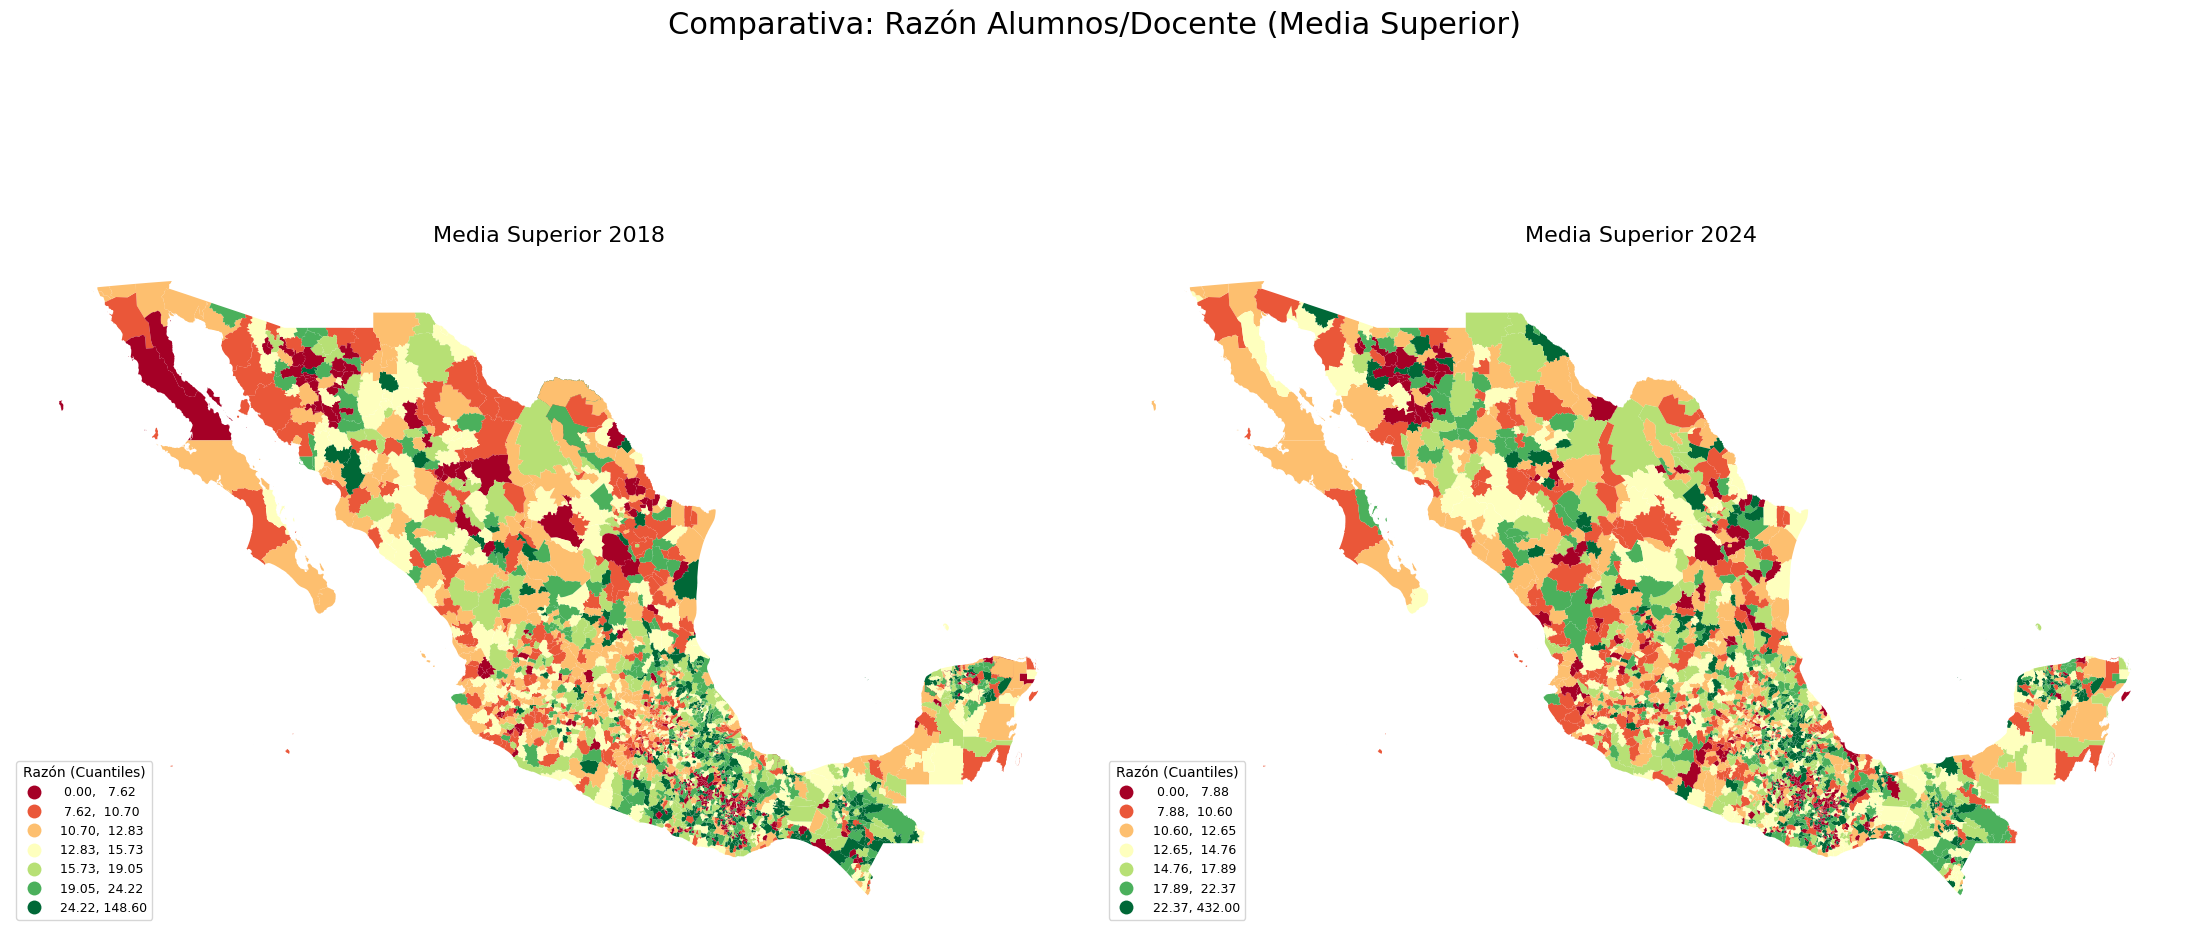

Generando Gráfica 2: Alumnos/Docente (Superior)


/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework/venv/lib/python3.14/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 7 classes. Setting k to 3.
  self.bins = quantile(y, k=k)
/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework/venv/lib/python3.14/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 7 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


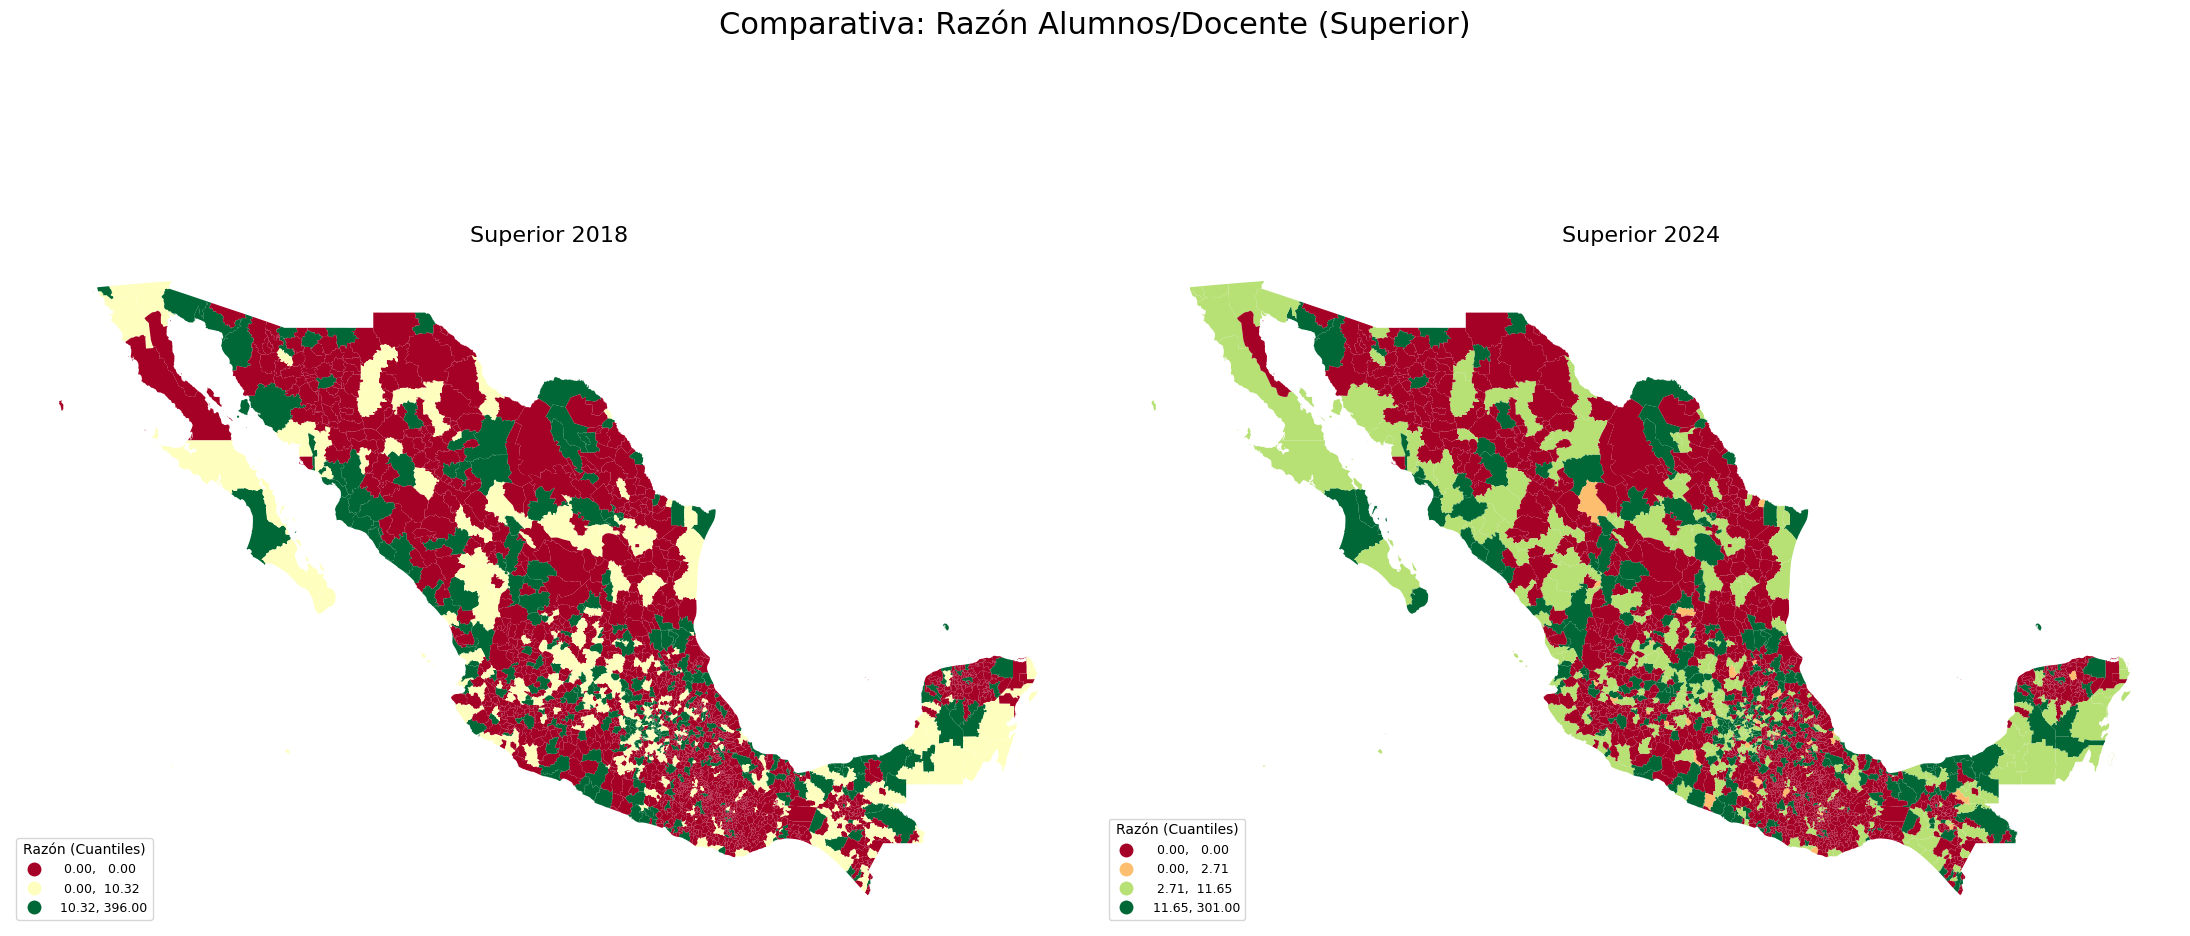

Generando Gráfica 3: Alumnos/Escuela (Media Superior)


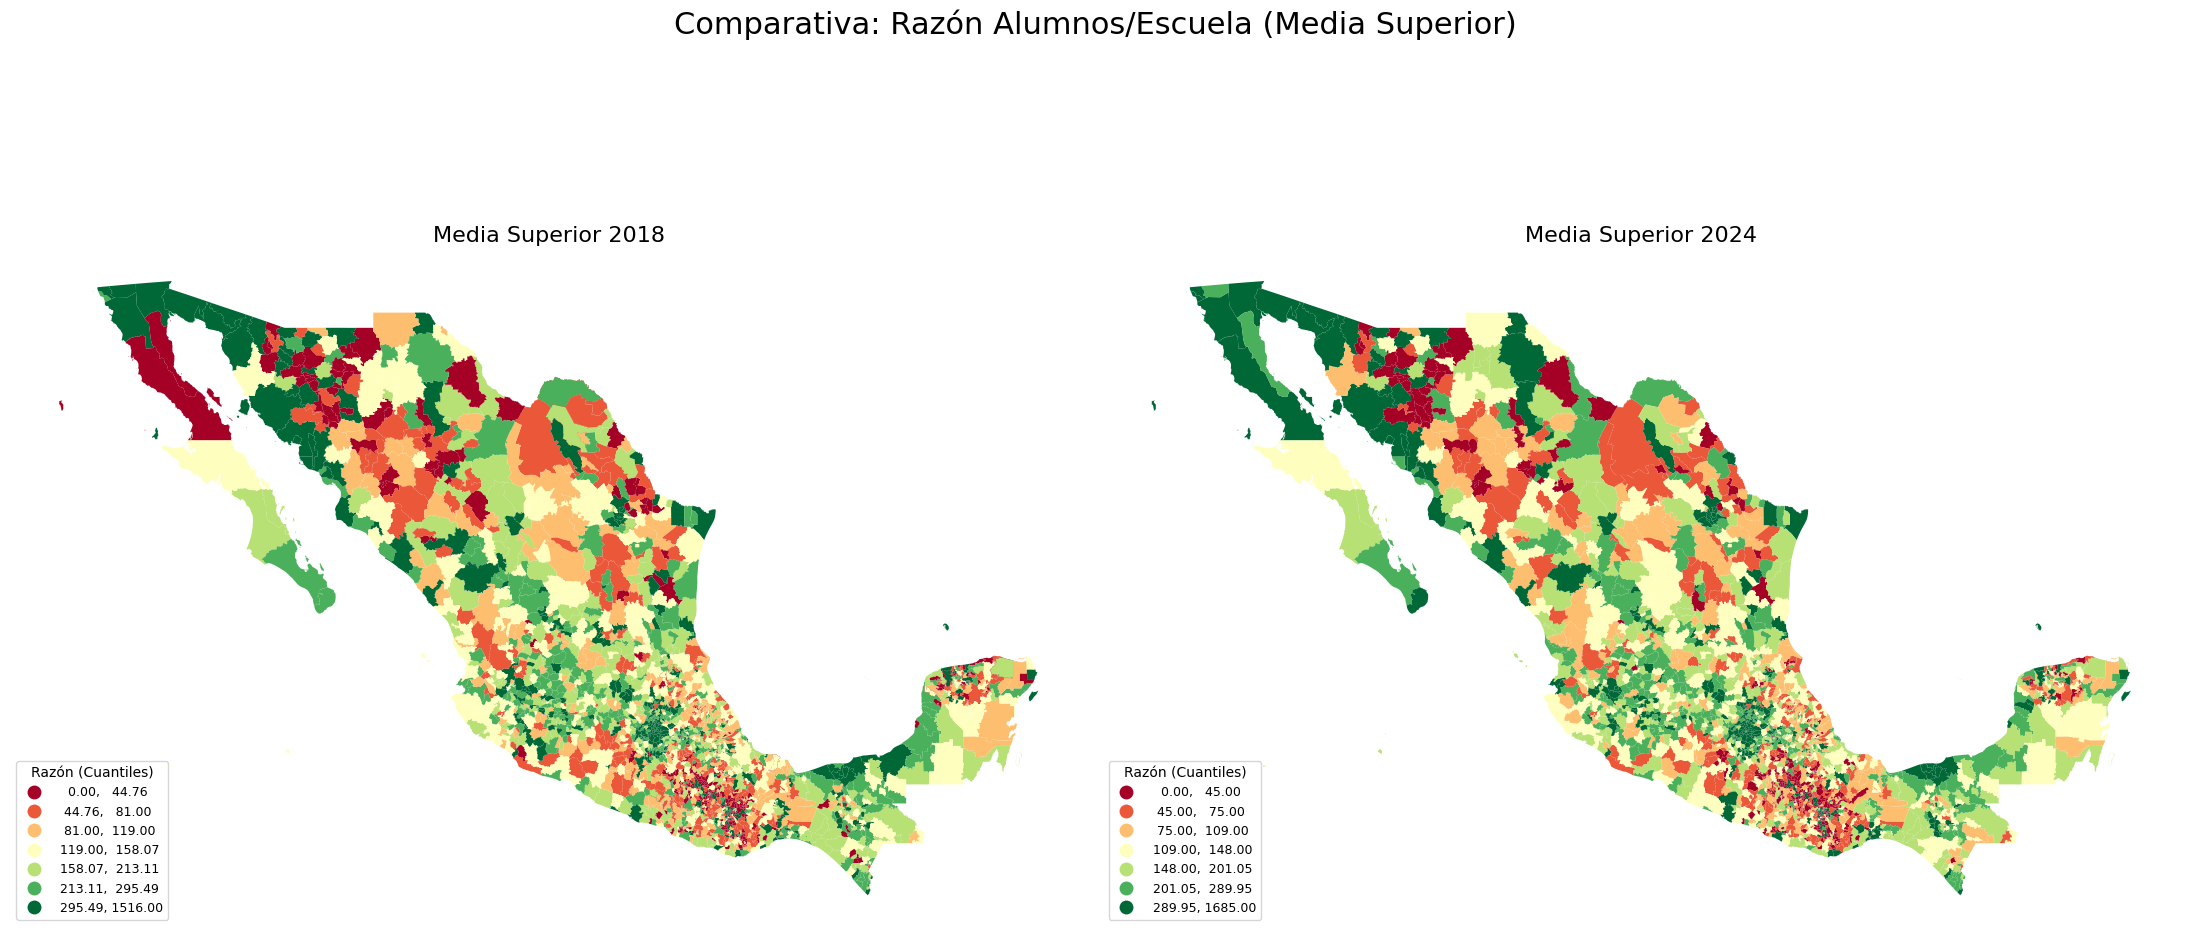

Generando Gráfica 4: Alumnos/Escuela (Superior)


/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework/venv/lib/python3.14/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 7 classes. Setting k to 3.
  self.bins = quantile(y, k=k)
/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework/venv/lib/python3.14/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 7 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


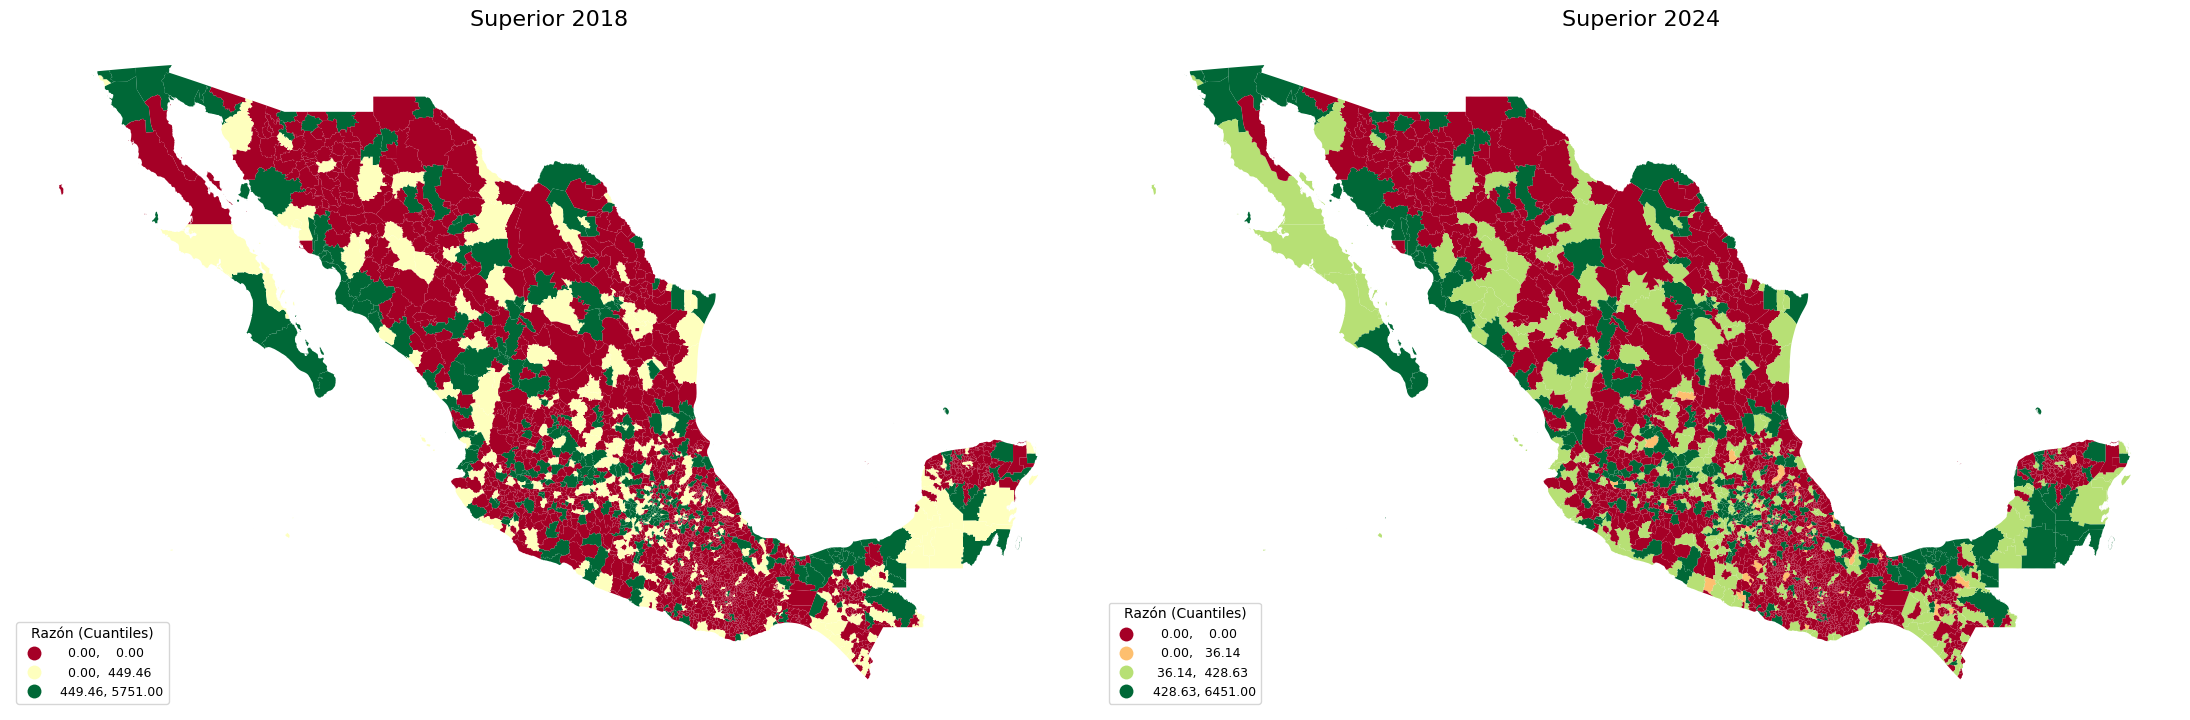



✅ 🎉 ¡Proceso de comparación completado! 🎉 ✅


In [8]:
# --- 0. INSTALACIÓN (Ejecutar solo una vez si es necesario) ---
# !pip install mapclassify

# --- 1. IMPORTAR LIBRERÍAS ---
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# --- 2. CARGA DE TODOS LOS DATOS ---
print("--- Iniciando Carga de Archivos ---")
try:
    # Definir rutas
    ruta_base = r"data/processed/mapas"
    ruta_mapa = r"data/processed/mapas"

    # Cargar 4 archivos CSV
    df_media_superior_2018 = pd.read_csv(f"{ruta_base}/media_superior_2018.csv", encoding='latin1')
    df_superior_2018 = pd.read_csv(f"{ruta_base}/superior_2018.csv", encoding='latin1')
    df_media_superior_2024 = pd.read_csv(f"{ruta_base}/media_superior_2024.csv", encoding='latin1')
    df_superior_2024 = pd.read_csv(f"{ruta_base}/superior_2024.csv", encoding='latin1')
    print("✅ 4 Archivos CSV cargados.")
    
    # Cargar Shapefile
    mx = gpd.read_file(ruta_mapa)
    print("✅ Shapefile 'mx' cargado.")

except Exception as e:
    print(f"❌ ERROR AL CARGAR ARCHIVOS: {e}")
    raise SystemExit("Deteniendo script por error en carga de archivos.")

# --- 3. PROCESAMIENTO Y PREPARACIÓN ---

# ⚠️ Nombres de columnas
col_alumnos = "Alumnos"
col_escuelas = "Escuelas"
col_docentes = "Docentes"
col_geo_datos = "ubicageo" 
col_geo_mapa = "CVEGEO"

def procesar_dataframe(df, df_nombre=""):
    """
    Toma un DataFrame, calcula las razones y prepara la clave geográfica.
    """
    try:
        df[col_alumnos] = pd.to_numeric(df[col_alumnos], errors='coerce')
        df[col_escuelas] = pd.to_numeric(df[col_escuelas], errors='coerce')
        df[col_docentes] = pd.to_numeric(df[col_docentes], errors='coerce')

        df['razon_alumnos_escuelas'] = np.where(df[col_escuelas] > 0, df[col_alumnos] / df[col_escuelas], 0)
        df['razon_alumnos_docentes'] = np.where(df[col_docentes] > 0, df[col_alumnos] / df[col_docentes], 0)
        
        df[col_geo_datos] = pd.to_numeric(df[col_geo_datos], errors='coerce')
        df[col_geo_datos] = df[col_geo_datos].astype('Int64')
        
        return df
    except KeyError as ke:
        print(f"❌ ERROR: La columna {ke} no se encontró en el archivo '{df_nombre}'.")
        return None
    except Exception as e:
        print(f"❌ ERROR procesando '{df_nombre}': {e}")
        return None

# Aplicamos la función a los 4 DataFrames
print("\n--- Procesando DataFrames ---")
df_media_superior_2018 = procesar_dataframe(df_media_superior_2018, "media_superior_2018")
df_superior_2018 = procesar_dataframe(df_superior_2018, "superior_2018")
df_media_superior_2024 = procesar_dataframe(df_media_superior_2024, "media_superior_2024")
df_superior_2024 = procesar_dataframe(df_superior_2024, "superior_2024")
print("✅ DataFrames procesados.")

# Preparamos la clave del mapa (Shapefile)
try:
    mx[col_geo_mapa] = pd.to_numeric(mx[col_geo_mapa], errors='coerce')
    mx[col_geo_mapa] = mx[col_geo_mapa].astype('Int64')
    print(f"✅ Clave '{col_geo_mapa}' adaptada a 'Int64' en el mapa 'mx'.")
except Exception as e:
    print(f"❌ ERROR procesando el mapa 'mx': {e}")


# --- 4. FUNCIÓN AUXILIAR PARA GRAFICAR EN UN EJE ---

def graficar_en_eje(mapa_base, datos_df, columna_a_graficar, ax, titulo_eje):
    """
    Toma un mapa base, datos, una columna, un eje (ax) y un título,
    y grafica el mapa en ESE eje.
    """
    if datos_df is None:
        print(f"⚠️ OMITIENDO MAPA: '{titulo_eje}' (Datos no disponibles).")
        ax.set_title(f"{titulo_eje}\n(Datos no disponibles)")
        ax.set_axis_off()
        return

    mapa_con_datos = mapa_base.merge(
        datos_df,
        left_on=col_geo_mapa,
        right_on=col_geo_datos,
        how='left' 
    )
    mapa_con_datos[columna_a_graficar] = mapa_con_datos[columna_a_graficar].fillna(0)
    
    try:
        mapa_con_datos.plot(
            column=columna_a_graficar,
            
            # --- ⬇️ AQUÍ ESTÁ LA CORRECCIÓN ⬇️ ---
            cmap='RdYlGn',           # Paleta Rojo-Amarillo-Verde
            # --- ⬆️ FIN DE LA CORRECCIÓN ⬆️ ---
            
            scheme='quantiles',      
            k=7,                     
            legend=True,
            ax=ax,
            legend_kwds={
                'loc': 'lower left',
                'ncol': 1,
                'frameon': True,
                'facecolor': 'white',
                'fontsize': 9,
                'title': 'Razón (Cuantiles)'
            },
            missing_kwds={
                "color": "lightgrey", 
                "label": "Sin datos", 
            }
        )
        ax.set_title(titulo_eje, fontsize=16)
        ax.set_axis_off()
    except Exception as e:
        print(f"❌ ERROR AL GRAFICAR '{titulo_eje}': {e}") 
        ax.set_title(f"{titulo_eje}\n(Error al graficar)")
        ax.set_axis_off()

# --- 5. EJECUCIÓN: GENERAR MAPAS COMPARATIVOS (2018 vs 2024) ---

print("\n--- INICIANDO GRÁFICAS COMPARATIVAS ---")

# --- COMPARATIVA 1: Alumnos/Docente (Media Superior) ---
print("Generando Gráfica 1: Alumnos/Docente (Media Superior)")
fig1, (ax1_1, ax1_2) = plt.subplots(1, 2, figsize=(22, 11)) 
fig1.suptitle("Comparativa: Razón Alumnos/Docente (Media Superior)", fontsize=22, y=0.98) 

graficar_en_eje(mx, df_media_superior_2018, "razon_alumnos_docentes", ax1_1, "Media Superior 2018")
graficar_en_eje(mx, df_media_superior_2024, "razon_alumnos_docentes", ax1_2, "Media Superior 2024")

plt.tight_layout(rect=[0, 0.0, 1, 0.95]) 
plt.show()


# --- COMPARATIVA 2: Alumnos/Docente (Superior) ---
print("Generando Gráfica 2: Alumnos/Docente (Superior)")
fig2, (ax2_1, ax2_2) = plt.subplots(1, 2, figsize=(22, 11))
fig2.suptitle("Comparativa: Razón Alumnos/Docente (Superior)", fontsize=22, y=0.98)

graficar_en_eje(mx, df_superior_2018, "razon_alumnos_docentes", ax2_1, "Superior 2018")
graficar_en_eje(mx, df_superior_2024, "razon_alumnos_docentes", ax2_2, "Superior 2024")

plt.tight_layout(rect=[0, 0.0, 1, 0.95])
plt.show()


# --- COMPARATIVA 3: Alumnos/Escuela (Media Superior) ---
print("Generando Gráfica 3: Alumnos/Escuela (Media Superior)")
fig3, (ax3_1, ax3_2) = plt.subplots(1, 2, figsize=(22, 11))
fig3.suptitle("Comparativa: Razón Alumnos/Escuela (Media Superior)", fontsize=22, y=0.98)

graficar_en_eje(mx, df_media_superior_2018, "razon_alumnos_escuelas", ax3_1, "Media Superior 2018")
graficar_en_eje(mx, df_media_superior_2024, "razon_alumnos_escuelas", ax3_2, "Media Superior 2024")

plt.tight_layout(rect=[0, 0.0, 1, 0.95])
plt.show()


# --- COMPARATIVA 4: Alumnos/Escuela (Superior) ---
print("Generando Gráfica 4: Alumnos/Escuela (Superior)")
fig4, (ax4_1, ax4_2) = plt.subplots(1, 2, figsize=(22, 11))
#fig4.suptitle("Comparativa: Razón Alumnos/Escuela (Superior)", fontsize=22, y=0.98)

graficar_en_eje(mx, df_superior_2018, "razon_alumnos_escuelas", ax4_1, "Superior 2018")
graficar_en_eje(mx, df_superior_2024, "razon_alumnos_escuelas", ax4_2, "Superior 2024")

plt.tight_layout(rect=[0, 0.0, 1, 0.95])
plt.show()


print("\n\n✅ 🎉 ¡Proceso de comparación completado! 🎉 ✅")

# UNIVERSIDADES

C:\Users\Jesus Sanchez\AppData\Local\Temp\ipykernel_33880\4245593607.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mx_est["centroid"] = mx_est.geometry.centroid


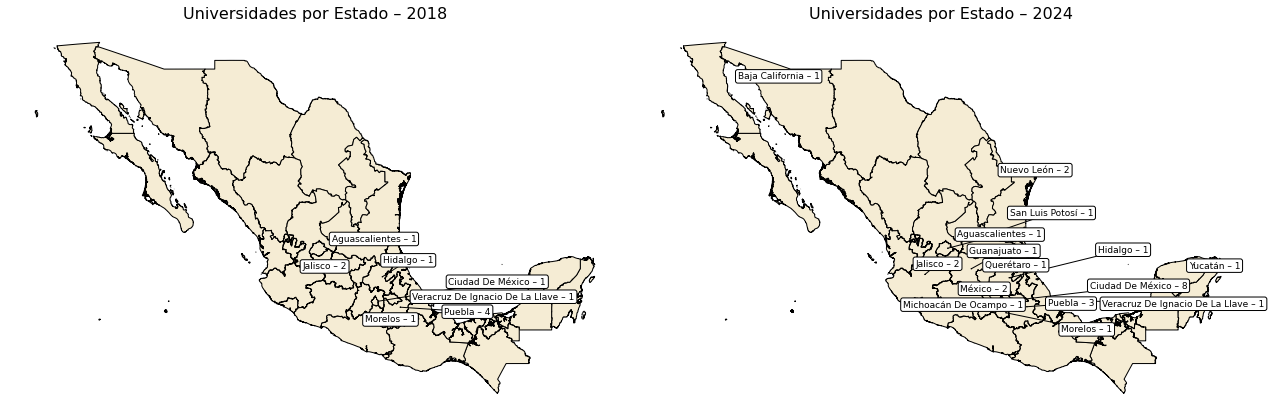

In [16]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from adjustText import adjust_text   # <- evita que las etiquetas se encimen

# --- 1. CARGA DEL MAPA BASE ---
ruta_mapa_estados = r"C:\Users\Jesus Sanchez\Desktop\ALEXIS\1. Estudio\Maestria BUAP - Economia\0. TESIS\Datos\dest_2010gw\dest_2010gw.shp"
mx_est = gpd.read_file(ruta_mapa_estados)

# Normalizar a mayúsculas
mx_est["ENTIDAD"] = mx_est["ENTIDAD"].str.upper().str.strip()

# >>> AQUÍ INICIA EL CAMBIO EN EL SHP <<<
# Diccionario: "Nombre Viejo/Sin Acento" : "Nombre Nuevo/Con Acento" (Tal como vienen en tu excel)
cambios_nombres = {
    "DISTRITO FEDERAL": "CIUDAD DE MÉXICO",
    "MEXICO": "MÉXICO",
    "MICHOACAN DE OCAMPO": "MICHOACÁN DE OCAMPO",
    "NUEVO LEON": "NUEVO LEÓN",
    "QUERETARO DE ARTEAGA": "QUERÉTARO",
    "SAN LUIS POTOSI": "SAN LUIS POTOSÍ",
    "YUCATAN": "YUCATÁN"
}

mx_est["ENTIDAD"] = mx_est["ENTIDAD"].replace(cambios_nombres)
# >>> AQUÍ TERMINA EL CAMBIO <<<

# --- 2. AGRUPAR POR ESTADO (evita etiquetas repetidas por islas) ---
mx_est = mx_est.dissolve(by="ENTIDAD", as_index=False)

# Centroides limpios
mx_est["centroid"] = mx_est.geometry.centroid


# --- 3. DATOS 2018 Y 2024 ---
data_2018 = {
    "Estado": [
        "Puebla", "Jalisco", "Veracruz de Ignacio de la Llave",
        "Hidalgo", "Ciudad de México", "Aguascalientes", "Morelos"
    ],
    "Numero": [4, 2, 1, 1, 1, 1, 1]
}

data_2024 = {
    "Estado": [
        "Ciudad de México", "Nuevo León", "México", "Puebla", "Jalisco",
        "Hidalgo", "Aguascalientes", "Baja California", "Veracruz de Ignacio de la Llave",
        "Guanajuato", "Yucatán", "Querétaro", "San Luis Potosí",
        "Morelos", "Michoacán de Ocampo"
    ],
    "Numero": [8, 2, 2, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}

df_2018 = pd.DataFrame(data_2018)
df_2024 = pd.DataFrame(data_2024)

df_2018["Estado"] = df_2018["Estado"].str.upper().str.strip()
df_2024["Estado"] = df_2024["Estado"].str.upper().str.strip()

# ... (justo después de estas líneas que ya tienes)
df_2018["Estado"] = df_2018["Estado"].str.upper().str.strip()
df_2024["Estado"] = df_2024["Estado"].str.upper().str.strip()



# --- 4. FUNCIÓN GENÉRICA ---
def graficar_mapa(ax, mapa, datos, titulo):

    merged = mapa.merge(datos, left_on="ENTIDAD", right_on="Estado", how="left")

    # Color beige claro
    merged.plot(ax=ax, color="#F5ECD4", edgecolor="black")

    # Lista para evitar etiquetas encimadas
    textos = []

    for i, row in merged.dropna(subset=["Numero"]).iterrows():
        cx, cy = row["centroid"].x, row["centroid"].y

        texto = f"{row['Estado'].title()} – {int(row['Numero'])}"

        anot = ax.text(
            cx, cy, texto,
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black")
        )

        textos.append(anot)

    # Ajuste automático para evitar empalmes
    adjust_text(textos, ax=ax, arrowprops=dict(arrowstyle="->", lw=1))

    ax.set_title(titulo, fontsize=16)
    ax.set_axis_off()


# --- 5. FIGURA LADO A LADO ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

graficar_mapa(ax1, mx_est, df_2018, "Universidades por Estado – 2018")
graficar_mapa(ax2, mx_est, df_2024, "Universidades por Estado – 2024")

plt.tight_layout()
plt.show()


# HOMICIDIOS



⏳ Generando visualización con subplots (2018 y 2024, horizontal)...


C:\Users\Jesus Sanchez\AppData\Local\Temp\ipykernel_11652\1272123288.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.14, 1, 0.95])


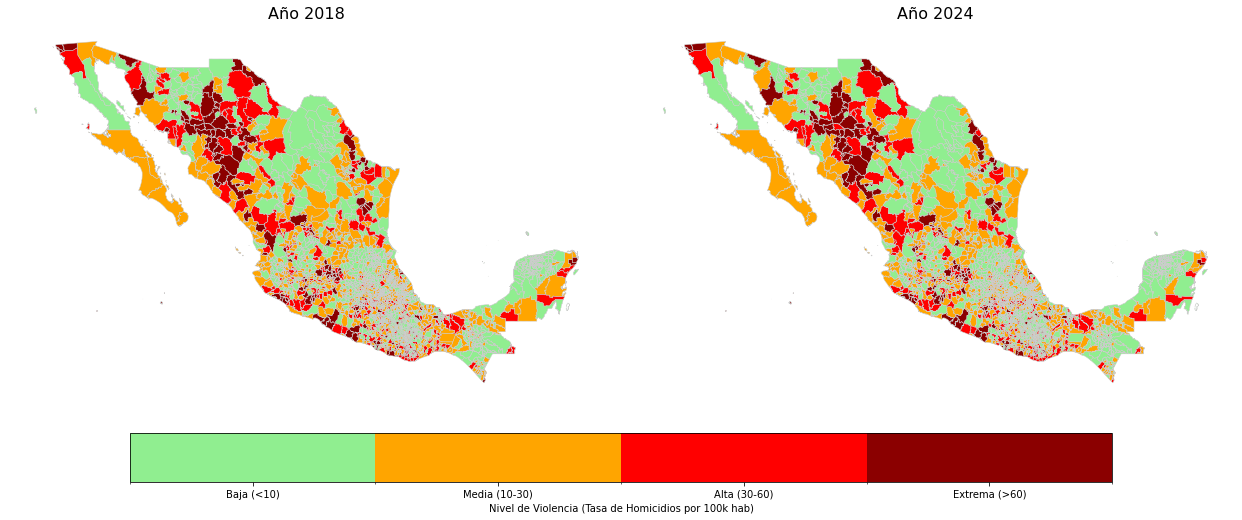

✅ Los dos mapas han sido generados horizontalmente, con la leyenda centrada abajo.


In [16]:
# --- 4. VISUALIZACIÓN DE MAPAS JUNTOS (SUBPLOTS: Lado a lado) ---

print("\n⏳ Generando visualización con subplots (2018 y 2024, horizontal)...")

# Creamos la figura con 1 fila y 2 columnas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 12), 
                               gridspec_kw={'wspace': 0.05, 'bottom': 0.12}) 
# wspace = espacio horizontal entre mapas

# Definir el mapa de colores categóricos para ambos plots
cmap_list = colores
cmap = ListedColormap(cmap_list)
bounds = np.arange(len(categorias) + 1) - 0.5 
norm = BoundaryNorm(bounds, cmap.N)

# ----------------------------------------------------
# 4.1 PLOT 1: Año 2018
# ----------------------------------------------------
mapa_2018.plot(column='nivel_violencia_num', 
               ax=ax1, 
               cmap=cmap, 
               norm=norm, 
               edgecolor='0.8', 
               linewidth=0.5, 
               missing_kwds={'color': 'lightgrey', 'label': 'Sin Datos'})

ax1.set_title('Año 2018', fontsize=16)
ax1.set_axis_off()

# ----------------------------------------------------
# 4.2 PLOT 2: Año 2024
# ----------------------------------------------------
mapa_2024.plot(column='nivel_violencia_num', 
               ax=ax2, 
               cmap=cmap, 
               norm=norm, 
               edgecolor='0.8', 
               linewidth=0.5, 
               missing_kwds={'color': 'lightgrey', 'label': 'Sin Datos'})

ax2.set_title('Año 2024', fontsize=16)
ax2.set_axis_off()

# ----------------------------------------------------
# 4.3 LEYENDA ÚNICA (Horizontal, centrada abajo)
# ----------------------------------------------------
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm),
                    ax=[ax1, ax2], 
                    orientation="horizontal",
                    shrink=0.8,
                    pad=0.05,
                    ticks=np.arange(len(categorias)),
                    label="Nivel de Violencia (Tasa de Homicidios por 100k hab)")

cbar.ax.set_xticklabels(categorias)

plt.tight_layout(rect=[0, 0.14, 1, 0.95])
plt.show()

print("✅ Los dos mapas han sido generados horizontalmente, con la leyenda centrada abajo.")
